# $$ \textbf{Sinais e Sistemas Dinâmicos - Unidade 2}$$


Este Notebook é utilizado para o estudo da disciplina  **Sinais e Sistemas Dinâmicos** através da bibliografia 

- [Análise Linear de Sinais, José C. Geromel, Grace S. Deaecto. ed. Blucher, 2019]

- [Sinais e Sistemas Lineares, B. P. Lathi, ed. bookman, 2014]

Quando aplicável utilizaremos a tolboox processamento de sinais *scipy*, a biblioteca de computação simbólica *sympy*, dentre outras que se fizerem necessárias, do Python.


In [4]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import* 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

from pylab import plot, show

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

#toolbox de processamento de sinais
from scipy import signal 

## 3. Análise de Sinais Periódicos


### 3.1 Introdução

Este seção é inteiramente dedicada ao estudo de sinais periódicos a tempo contínuo e a tempo discreto. Uma entidade matemática absolutamente singular denominada **Série de Fourier** será apresentada e analisada com bastante detalhe. 

Em linhas gerais, *podemos dizer que qualquer sinal periódico definido no domínio do tempo, em $\mathbb{R}$ ou $\mathbb{Z}$, pode ser decomposto em um número infinito de componentes que compõem o seu espectro de frequências*. 

A luz, por exemplo, é um sinal que tem um espectro denominado espectro eletromagnético bem conhecido. A série de Fourier permite decompor e aproximar um sinal através de uma combinação linear das suas componentes fundamentais. Como consequência, permite também calcular a sua potência média através de um resultado importante e famoso denominado **Teorema de Parseval**. 

O estudo começa com a formulação e resolução de um **problema de erro quadrático mínimo**, cuja solução se torna uma ferramenta essencial para o estudo de sinais e sistemas.

### 3.2 Representação de Sinais
Considere um conjunto de vetores $v_i \in \mathbb{R}^n$ para todo $i=1, \cdots, m$ em que $m \leq n$. Uma pergunta importante que deve ser respondida é: dado um vetor $y \in \mathbb{R}^n$, existem constantes $\alpha_i \in \mathbb{R}, i=1,2, \cdots, m$ não todas nulas de tal forma que $y$ seja expresso como $y=\sum_{i=1}^m \alpha_i v_i$ ? A resposta a esta pergunta, que pode ou não ser afirmativa, permitiu o desenvolvimento de importantes conceitos em diversas áreas da matemática, tais como os de combinação linear e de base em um espaço vetorial. Como $y$ é um vetor arbitrário com $n$ componentes, a resposta, para ser afirmativa, exige que $m=n$ e que os vetores sejam **linearmente independentes**, o que quer dizer que a matriz quadrada $V=\left[\begin{array}{lll}v_1 & \cdots & v_n\end{array}\right] \in \mathbb{R}^{n \times n}$ deve ser não singular $\operatorname{det}(V) \neq 0$. 

No estudo de sinais a tempo contínuo $g(t)$ com domínio $\mathbb{R}$ e imagem $\mathbb{C}$, desejamos determinar um conjunto de $m$ (que pode ser infinito) sinais $f_i(t), i=$ $1,2, \cdots, m$ com os mesmos domínios e imagens, de tal forma que existam escalares $\alpha_i \in \mathbb{C}, \forall i=1,2, \cdots, m$ capazes de garantir a igualdade
$$
g(t)=\sum_{i=1}^m \alpha_i f_i(t), \forall t \in \mathbb{R}
$$
Neste sentido, formulamos o seguinte problema de otimização denominado **erro quadrático mínimo**

$$
\min _{\alpha_1, \alpha_2, \cdots, \alpha_m}\left\|g-\sum_{i=1}^m \alpha_i f_i\right\|^2
$$
em que $\|\cdot\|$ é a norma induzida pelo produto interno. 

A solução ótima deste problema remete ao Teorema de Pitágoras, pois exige ortogonalidade. De fato, para cada conjunto de parâmetros $\alpha_1, \alpha_2, \cdots, \alpha_m$ escolhidos definimos o **sinal de erro** como sendo
$$
\epsilon(t)=g(t)-\sum_{i=1}^m \alpha_i f_i(t), \quad \forall t \in \mathbb{R}
$$

e para resolver o problema de otimização devemos determinar os parâmetros, que são as nossas variáveis de decisão, de tal forma que a norma do erro seja a menor possível (idealmente, zero). 

A Figura 3.1 ilustra o que ocorre com as funções transformadas em vetores para que a ilustração geométrica seja possível. A combinação ótima de $f_1$ e $f_2$ deve gerar um ponto que é exatamente a projeção ortogonal do ponto $O$ no plano definido por $f_1$ e $f_2$, pois essa situação define a menor distância entre o ponto $O$ e qualquer ponto do referido plano. Dito de outra forma, o erro deve ser ortogonal a $f_1$ e a $f_2$.

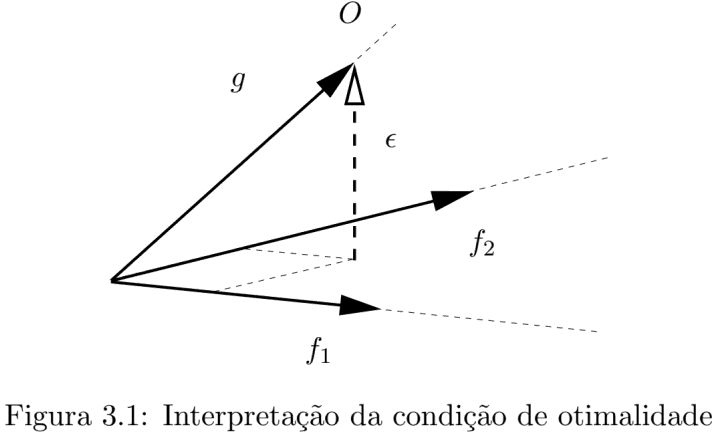

Retomando o problema do erro quadrático mínimo, sua condição de otimalidade se expressa na forma $\left\langle\epsilon, f_n\right\rangle=0$ para todo $n=1,2, \cdots, m$, o que leva ao sistema de equações lineares
$$
\left\langle g, f_n\right\rangle-\sum_{i=1}^m \alpha_i\left\langle f_i, f_n\right\rangle=0, \quad n=1,2, \cdots, m
$$
Trata-se de um sistema com $m$ equações e $m$ incógnitas que depende de alguma condição para que possa se resolvido e, eventualmente, tenha solução única. Isto ocorre sempre que os sinais que constituem a base $f_i, i=1,2, \cdots, m$ forem ortogonais entre si. 

Na equação acima este fato que se traduz por $\left\langle f_i, f_n\right\rangle=0$ para todo $i \neq n=1,2, \cdots, m$, as equações se desacoplam e fornecem imediatamente a solução procurada

$$
\alpha_i=\frac{\left\langle g, f_i\right\rangle}{\left\langle f_i, f_i\right\rangle}, i=1,2, \cdots, m
$$
Tendo conhecimento da solução ótima, podemos avaliar o valor mínimo da norma ao quadrado do erro correspondente, que é dado por
$$
\begin{aligned}
\|\epsilon\|^2 & =\left\langle\epsilon, g-\sum_{i=1}^m \alpha_i f_i\right\rangle \\
& =\left\langle g-\sum_{i=1}^m \alpha_i f_i, g\right\rangle \\
& =\|g\|^2-\sum_{i=1}^m\left|\alpha_i\right|^2\left\|f_i\right\|^2
\end{aligned}
$$
onde utilizamos a relação que decorre de $\alpha_i=\frac{\left\langle g, f_i\right\rangle}{\left\langle f_i, f_i\right\rangle}, i=1,2, \cdots, m $ e permite determinar o conjugado do parâmetro ótimo
$$
\begin{aligned}
\alpha_i^* & =\frac{\left\langle g, f_i\right\rangle^*}{\left\langle f_i, f_i\right\rangle} \\
& =\frac{\left\langle f_i, g\right\rangle}{\left\|f_i\right\|^2}
\end{aligned}
$$
O ponto central é como escolher um conjunto de funções ortogonais de tal forma que para sinais de uma certa classe sempre existam parâmetros $\alpha_i \in \mathbb{C}, i=$ $1,2, \cdots, m$ que tornem o erro nulo. 

Como veremos em seguida, esta talvez seja a maior contribuição de Fourier ao propor uma base para os sinais periódicos a tempo contínuo ou a tempo discreto que exibe esta importante propriedade.

**Exemplo 3.1** Não é difícil construir uma base ortogonal de sinais. Uma possibilidade é fazer $f_i(t)=v\left(t-\tau_i\right)-v\left(t-\tau_{i+1}\right)$, em que $\tau_{i+1}-\tau_i=d>0$ com $i \in \mathbb{Z}$. O $i$-ésimo sinal é igual a 1 para todo $\tau_i \leq t<\tau_{i+1}$ e zero para todo $t \in \mathbb{R}$ fora deste intervalo. Portanto, todos são ortogonais entre si. Ademais, é fácil determinar $\left\|f_i\right\|^2=\tau_{i+1}-\tau_i$ e que para um sinal $g(t)$ dado
$$
\alpha_i=\frac{1}{\tau_{i+1}-\tau_i} \int_{\tau_i}^{\tau_{i+1}} g(t) d t
$$
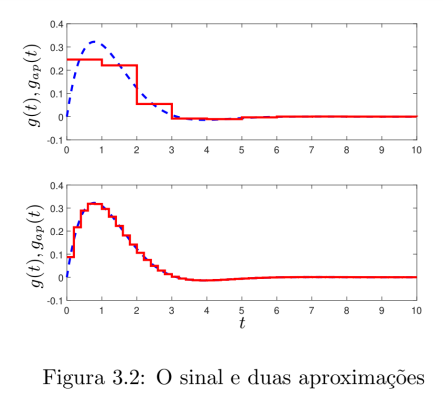

A Figura 3.2 ilustra este resultado aplicado ao sinal $g(t)=e^{-t} \operatorname{sen}(t) v(t)$. Na sua parte superior aparece o sinal $g(t)$ e a função aproximada $g_{a p}(t)=\sum_{i=0}^{\infty} \alpha_i f_i(t) \operatorname{com} d=1[\mathrm{~s}]$. Nota-se uma grande diferença entre as duas funções, o que indica um erro quadrático mínimo bastante elevado. Na parte inferior mostramos o mesmo sinal e sua aproximação, mas com $d=0.2$. A redução do erro quadrático mínimo é visível. Para $d \rightarrow 0^{+}$ele tende a zero.

### 3.3 Sinais a Tempo Contínuo
Consideramos, exclusivamente, sinais periódicos com período $T_0>0$ a tempo contínuo com domínio em $\mathbb{R}$ e com imagem $\mathbb{C}$. Em várias situações, que são as mais importantes em aplicações práticas, a imagem do sinal de interesse será o conjunto dos números reais $\mathbb{R}$. Como já sabemos, um sinal $g(t)$ é periódico se existir $T_0>0$ tal que $t+T_0 \in \mathbb{R}$ para todo $t \in \mathbb{R}$ e
$$
g(t)=g\left(t+T_0\right), \forall t \in \mathbb{R}
$$
o menor $T_0$ que satisfaz estas condições é o seu período fundamental. 

Para esta classe de sinais, vamos restringir o seu domínio a $t \in\left[0, T_0\right] \subset \mathbb{R}$, pois toda propriedade que vale para um período vale também para todos os demais. 

O resultado central, neste caso, diz respeito à existência de um conjunto infinito de sinais ortogonais, a saber
$$
f_i(t)=e^{j \omega_i t}, \omega_i=\frac{2 \pi}{T_0} i
$$

para todo $i \in \mathbb{Z}$. As frequências $\omega_i$, expressas em $[\mathrm{rad} / \mathrm{s}]$, são denominadas **harmônicas**, ou seja, $\omega_1$ é a **primeira harmônica**, $\omega_2$ a **segunda harmônica** e assim por diante. 

Ao restringirmos nossa atenção a apenas um período, podemos verificar sem dificuldades que, de fato, todos estes sinais são ortogonais entre si. 

Adaptando a *definiçāo de produto escalar de sinais com domínio em $t \in\left[0, T_0\right] \mathrm{e}$ imagem $\mathbb{C}$*, temos imediatamente que
$$
\left\langle f_i, f_n\right\rangle=\int_0^{T_0} e^{j\left(\omega_i-\omega_n\right) t} d t=\left\{\begin{array}{cc}
T_0, & i=n \\
0, & i \neq n
\end{array}\right.
$$
Para este conjunto de sinais, com $\alpha_i=\frac{\left\langle g, f_i\right\rangle}{\left\langle f_i, f_i\right\rangle}, i=1,2, \cdots, m$, podemos calcular os coeficientes que correspondem ao erro quadrático mínimo, ou seja,
$$
\alpha_i=\frac{1}{T_0} \int_0^{T_0} g(t) e^{-j \omega_i t} d t, i \in \mathbb{Z}
$$
e concluir que, se o erro quadrático mínimo for nulo, então a seguinte igualdade
$$
g(t)=\sum_{i=-\infty}^{\infty} \alpha_i e^{j \omega_i t}, t \in \mathbb{R}
$$
é válida. Isto decorre de $g(t)$ ser um sinal periódico, com período $T_0>0$. Como o erro é periódico com período $T_0>0$, se ele for nulo em um período, então ele será nulo em todos os demais períodos, ou seja, para todo $t \in \mathbb{R}$. O próximo lema torna explícita as condições para que a última igualdade ocorra.

**Lema 3.1** Os sinais $\left\{f_i\right\}_{i \in \mathbb{Z}}$ definidos em $f_i(t)=e^{j \omega_i t}, \omega_i=\frac{2 \pi}{T_0} i$ formam um **conjunto completo**, isto é, o erro quadrático mínimo
$$
\|\epsilon\|^2=\int_0^{T_0}|\epsilon(t)|^2 d t
$$
é nulo.

A prova deste resultado vai além do escopo deste curso e, portanto, será omitida. É preciso ficar claro que isto não implica que $\epsilon(t)=0$ para todo $t \in\left[0, T_0\right)$. De fato, pode ocorrer que $\epsilon(t) \neq 0$ em pontos isolados e a integral acima se mantenha nula. Isto ocorre nos pontos onde o sinal $g(t)$ é descontínuo, o que é muito frequente, sobretudo nos pontos extremos dos intervalos de tempo $t \in\left[k T_0,(k+1) T_0\right)$ $\operatorname{com} k \in \mathbb{Z}$ que se sucedem indefinidamente. 

Este e outros importantes aspectos serão ilustrados através dos exemplos que passamos a discutir em seguida. 

<p style="color: blue">A expressão
$$
g(t)=\sum_{i=-\infty}^{\infty} \alpha_i e^{j \omega_i t}, t \in \mathbb{R}
$$ 
com $\alpha_i, i \in \mathbb{Z}$ dados em 
$$
\alpha_i=\frac{1}{T_0} \int_0^{T_0} g(t) e^{-j \omega_i t} d t, i \in \mathbb{Z}
$$
é denominada Série de Fourier do sinal $g(t)$.</p>


**Exemplo 3.2** Vamos determinar a série de Fourier para um sinal periódico cujo primeiro período é dado por
$$
g(t)=\left\{\begin{array}{ccc}
1 & , & |t| \leq a / 2 \\
0 & , & a / 2<|t| \leq T_0 / 2
\end{array}\right.
$$
a relaçāo $r=a / T_0$ é o seu **fator de ocupaçāo**. Trata-se de um sinal conhecido como **trem de pulsos**. 

Com $\alpha_i=\frac{1}{T_0} \int_0^{T_0} g(t) e^{-j \omega_i t} d t, i \in \mathbb{Z}$, determinamos os coeficientes da série, sendo que mudamos os limites de integração para facilitar os cálculos. O resultado permanece inalterado pois mantém-se a integração em um período completo. Obtemos
$$
\begin{aligned}
\alpha_i & =\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} g(t) e^{-j \omega_i t} d t \\
& =\frac{1}{T_0} \int_{-a / 2}^{a / 2} e^{-j \omega_i t} d t \\
& =\frac{a}{T_0} \operatorname{sinc}\left(\omega_i a / 2\right)
\end{aligned}
$$
para todo $i \in \mathbb{Z}$. Como $\omega_i a / 2=\pi\left(a / T_0\right) i$, cada coeficiente $\alpha_i$ depende apenas do fator de ocupação $r$. 


A Figura 3.3 mostra três períodos do sinal $g(t) \operatorname{com} T_0=1[\mathrm{~s}], a=0,25$ e as aproximações obtidas pelo truncamento da série de Fourier $g_m(t)=\sum_{i=-m}^m \alpha_i e^{j \omega_i t} \mathrm{com}$ $m \in\{2,5,20,50\}$. 

In [1]:
#from sympy import fourier_series, pi, plot
from sympy.abc import t
g = sym.Piecewise((1, (-0.25 <= t) & (t <=0.25)), (0, True))
s = fourier_series(g, (t, -0.5, 0.5))
s1 = s.truncate(n = 2)
s2 = s.truncate(n = 5)
s3 = s.truncate(n = 20)
s4 = s.truncate(n = 50)

g = sym.Piecewise((1, (-0.25 <= t) & (t <=0.25)), (1, (-1.25 <= t) & (t <=- 0.75)), 
                  (1, (0.75 <= t) & (t <=1.25)), (1, (1.75 <= t) & (t <=2.25)), 
                  (1, (-2.25 <= t) & (t <=-1.75)), (0, True))

p1 = sym.plot(g, s1, (t, -2, 2), title='Figura 3.3 - $m=2$', show=False, legend=True)
p2 = sym.plot(g, s2, (t, -2, 2), title='Figura 3.3 - $m=5$', show=False, legend=True)
p3 = sym.plot(g, s3, (t, -2, 2), title='Figura 3.3 - $m=20$', show=False, legend=True)
p4 = sym.plot(g, s4, (t, -2, 2), title='Figura 3.3 - $m=50$', show=False, legend=True)

p1[0].line_color = 'b'
p1[0].label = '$g(t)$'
p2[0].line_color = 'b'
p2[0].label = '$g(t)$'
p3[0].line_color = 'b'
p3[0].label = '$g(t)$'
p4[0].line_color = 'b'
p4[0].label = '$g(t)$'
p1[1].line_color = 'r'
p1[1].label = 'm=2'
p2[1].line_color = 'r'
p2[1].label = 'm=5'
p3[1].line_color = 'r'
p3[1].label = 'm=20'
p4[1].line_color = 'r'
p4[1].label = 'm=50'


NameError: name 'sym' is not defined

In [ ]:
p1.show()

In [ ]:
p2.show(), p3.show(), p4.show()

**Exemplo 3.3** Um caso interessante é o sinal periódico denominado **trem de impulsos**, definido por 
$$g(t)=\sum_{k=-\infty}^{\infty} \delta\left(t-k T_0\right),$$ que é muito parecido com o sinal do exemplo anterior, mas com os pulsos sendo substituídos por impulsos unitários. 

Com $\alpha_i=\frac{1}{T_0} \int_0^{T_0} g(t) e^{-j \omega_i t} d t, i \in \mathbb{Z}$ determinamos os coeficientes da série de Fourier como sendo
$$
\alpha_i=\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} \delta(t) e^{-j \omega_i t} d t=\frac{1}{T_0}
$$
para todo $i \in \mathbb{Z}$ e, assim, estabelece-se a igualdade
$$
\sum_{k=-\infty}^{\infty} \delta\left(t-k T_0\right)=\frac{1}{T_0} \sum_{i=-\infty}^{\infty} e^{j\left(2 \pi / T_0\right) i t}, \forall t \in \mathbb{R}
$$

Esta relação é muito útil em diversas situações e deve ser entendida de uma maneira peculiar. Para todo $t \in \mathbb{R}$ a série de Fourier assume valores reais. Ademais, para todo $t \neq k T_0, \forall k \in \mathbb{Z}$, a série converge para zero. Nos instantes $t=k T_0, \forall k \in \mathbb{Z}$, a série de Fourier diverge para $+\infty$ com a forma de um impulso, tendo em vista que
$$
\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} \sum_{i=-\infty}^{\infty} e^{j\left(2 \pi / T_0\right) i t} d t=\sum_{i=-\infty}^{\infty} \operatorname{sinc}(\pi i)=1
$$

ou seja, a integral no interior do primeiro período é igual a um. A divergência da série de Fourier, nesses instantes de tempo, não ocorre de qualquer maneira, pois sua integral, em cada período, se mantém constante.

**Exemplo 3.4** Vamos agora obter a série de Fourier de um sinal denominado **dente de serra**, cujo primeiro período é definido por $g(t)=a t,|t| \leq T_0 / 2$, em que $a \in$ $\mathbb{R}$. Novamente com $\alpha_i=\frac{1}{T_0} \int_0^{T_0} g(t) e^{-j \omega_i t} d t, i \in \mathbb{Z}$, determinamos os coeficientes da série de Fourier, que são dados por $\alpha_0=0$ e
$$
\begin{aligned}
\alpha_i & =\frac{a}{T_0} \int_{-T_0 / 2}^{T_0 / 2} t e^{-j \omega_i t} d t \\
& =j \frac{a T_0}{2 \pi i} \cos (\pi i) + \frac{aT_0}{2 \pi^2 i^2} \sin(\pi i) \\
& =j \frac{a T_0}{2 \pi i} \cos (\pi i)
\end{aligned}
$$

para todo $0 \neq i \in \mathbb{Z}$. Observamos que os coeficientes são números imaginários puros, mas a aproximação $g_m(t)=\sum_{i=-m}^m \alpha_i e^{j \omega_i t}$ fornece um valor real tendo em vista que o sinal $g(t)$ é real. A Figura 3.4 mostra o sinal com $T_0=1[\mathrm{~s}]$ e $a=2$ e as aproximações obtidas com $m=2$ e $m=20$. Nota-se novamente que, nos pontos de descontinuidade, as duas aproximações fornecem os valores médios do sinal naquele ponto. Observa-se também como a série de Fourier converge rapidamente, isto é, com um número relativamente pequeno de termos.

In [ ]:
#from sympy import fourier_series
#from sympy.abc import t
g = sym.Piecewise((2*t, (-0.5 <= t) & (t <=0.5)), (0, True))
s = fourier_series(g, (t, -0.5, 0.5))
s1 = s.truncate(n = 2)
s2 = s.truncate(n = 20)
s5 = s.truncate(n = 5)

g = sym.Piecewise((2*t, (-0.5 <= t) & (t <=0.5)),
                  (2*(t - 1), (0.5 <= t) & (t <=1.5)), 
                  (2*(t + 1), (-1.5 <= t) & (t <=-0.5)))

p1 = sym.plot(g, s1, (t, -1.4, 1.4), title='Figura 3.4 - $m=2$', show=False, legend=True)
p2 = sym.plot(g, s2, (t, -1.4, 1.4), title='Figura 3.4 - $m=20$', show=False, legend=True)

p1[0].line_color = 'b'
p1[0].label = '$g(t)$'
p2[0].line_color = 'b'
p2[0].label = '$g(t)$'
p1[1].line_color = 'r'
p1[1].label = 'm=2'
p2[1].line_color = 'r'
p2[1].label = 'm=20'

p1.show()

In [ ]:
p2.show()

**Exemplo 3.5 (Fenômeno de Gibbs)** Os exemplos anteriores mostram um fenômeno, até certo ponto inesperado, que ocorre quando se faz o truncamento da série de Fourier. Era de se esperar que o truncamento $g_m(t)=\sum_{i=-m}^m \alpha_i e^{j \omega_i t}$ fornecesse aproximações mais precisas com o aumento de $m$. Isto ocorre em todos os pontos, salvo naqueles em que o sinal $g(t)$ não é contínuo. Neles, os exemplos sempre mostram que, com o aumentar de $m$, picos maiores aparecem. Estes picos têm valores limitados e têm duração temporal cada vez menor, de tal forma que o erro quadrático mínimo não é impactado.

**Exemplo 3.6 (Espectro)** Os gráficos do módulo e do argumento dos coeficientes $\alpha_i \in$ $\mathbb{C}$ em função das frequências $\omega_i$ para todo $i \in \mathbb{Z}$ (ou, de forma equivalente, em função de $i \in \mathbb{Z}$ ) definem os **espectros de módulo e de fase** do sinal periódico $g(t)$. 

Para o Exemplo 3.4 o espectro de módulo é o gráfico de $\left(a T_0\right) /(2 \pi i)$ e o espectro de fase é o gráfico de $(\pi / 2) \cos (\pi i)$, ambos em função de $\omega_i$ para todo $i \in \mathbb{Z}$.

A série de Fourier permite calcular o valor eficaz (ou a potência média) de um determinado sinal manipulando diretamente os seus coeficientes. Esta propriedade decorre do **Teorema de Parseval**, um resultado bastante conhecido que tem larga utilização no estudo de sinais e sistemas.

**Teorema 3.1 (Teorema de Parseval)**  Se $\alpha_i \in \mathbb{C}$ são os coeficientes da série de Fourier do sinal $g(t)$, então
$$
\|g\|_{e f}^2=\sum_{i=-\infty}^{\infty}\left|\alpha_i\right|^2
$$

**Prova:** A prova é feita de maneira direta pelo cálculo do valor eficaz do sinal e e pelo uso da relação $g(t)=\sum_{i=-\infty}^{\infty} \alpha_i e^{j \omega_i t}, t \in \mathbb{R}$ cuja validade é assegurada pela série de Fourier. Neste sentido, temos
$$
\begin{aligned}
\|g\|_{e f}^2 & =\frac{1}{T_0} \int_0^{T_0} g(t) g(t)^* d t \\
& =\frac{1}{T_0} \sum_{i=-\infty}^{\infty} \sum_{n=-\infty}^{\infty} \alpha_i \alpha_n^* \int_0^{T_0} e^{j\left(\omega_i-\omega_n\right) t} d t \\
& =\sum_{i=-\infty}^{\infty} \alpha_i \alpha_i^*
\end{aligned}
$$

A prova do Teorema de Parseval coloca em clara evidência que o seu resultado assenta-se na ortogonalidade dos sinais elementares adotados na série de Fourier.

Como cada elemento da soma em $\|g\|_{e f}^2=\sum_{i=-\infty}^{\infty}\left|\alpha_i\right|^2$ é não negativo e o resultado final é limitado para sinais de potência limitada, certamente ocorrerá $\lim _{|i| \rightarrow \infty}\left|\alpha_i\right|=0$. Ou seja, os termos subsequentes da série de Fourier tendem a perder importância para o cálculo do valor eficaz do sinal.

Existem algumas relações úteis entre os coeficientes da série de Fourier. Note, por exemplo que 

$$
\begin{aligned}
\alpha_i^* & =\frac{1}{T_0} \int_0^{T_0} g(t) e^{+j\omega_i t} d t \\
 & =\frac{1}{T_0} \int_0^{T_0} g(t) e^{-j\omega_{-i} t} d t \\
 & =\alpha_{-i}
\end{aligned}
$$

Portanto, os coeficientes situados em posições simétricas em relação à origem são complexos conjugados. 

Ademais, reescrevendo $\alpha_i=\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} g(t) e^{-j \omega_i t} d t$ na forma equivalente 
$$
\alpha_i=\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} g(t)\left(\cos \left(\omega_i t\right)-j \operatorname{sen}\left(\omega_i t\right)\right) d t
$$

para todo $i \in \mathbb{Z}$, fica claro que, se o sinal for par, então $\operatorname{Im}\left(\alpha_i\right)=0 $ e, assim, todos os coeficientes são reais. Por outro lado, se o sinal for ímpar, então $\operatorname{Re}\left(\alpha_i\right)=0$ e, assim, todos os coeficientes são imaginários puros. Os dois casos foram ilustrados através dos Exemplos 3.2 e 3.4, respectivamente. Estas relações podem ser úteis para a verificação de cálculos realizados em situações específicas.

A série de Fourier é uma ferramenta bastante eficaz para se calcular a resposta de um sistema LIT causal, definido pelo operador linear $\mathcal{S}[\cdot]$, a um sinal de entrada genérico, mas periódico. 

O Exemplo 2.15 da unidade anterior estabelece que $\mathcal{S}\left[e^{j \omega_i t}\right]=\hat{h}\left(j \omega_i\right) e^{j \omega_i t} \operatorname{com}$
$$
\hat{h}\left(j \omega_i\right)=\int_0^{\infty} e^{-j \omega_i t} h(t) d t
$$

sendo $h(t)$ a resposta ao impulso do sistema em consideração. 

Desenvolvendo a entrada periódica $g(t)$ em série de Fourier, com $g(t)=\sum_{i=-\infty}^{\infty} \alpha_i e^{j \omega_i t}$, a resposta $y(t)$ correspondente a esta entrada é determinada através de
$$
\begin{aligned}
y(t) & =\mathcal{S}\left[\sum_{i=-\infty}^{\infty} \alpha_i e^{j \omega_i t}\right] \\
& =\sum_{i=-\infty}^{\infty} \alpha_i \mathcal{S}\left[e^{j \omega_i t}\right] \\
& =\sum_{i=-\infty}^{\infty} \alpha_i \hat{h}\left(j \omega_i\right) e^{j \omega_i t}
\end{aligned}
$$

Portanto, se definirmos $\beta_i=\alpha_i \hat{h}\left(j \omega_i\right)$ para todo $i \in \mathbb{Z}$, podemos concluir que a resposta do sistema é um sinal periódico, com o mesmo período do sinal de entrada, sendo $\beta_i$ para todo $i \in \mathbb{Z}$ os coeficientes da sua série de Fourier. Este fato tem uma consequência interessante. A resposta a qualquer sinal com domínio real resulta em um sinal de saída real, o que implica em termos $\beta_{-i}=\beta_i^*$ sempre que $\alpha_{-i}=\alpha_i^*$ para todo $i \in \mathbb{Z}$. Levando em conta que $\omega_{-i}=-\omega_i$, estes cálculos levam à conclusão de que
$$
\hat{h}\left(-j \omega_i\right)=\hat{h}\left(j \omega_i\right)^*
$$

para todo $i \in \mathbb{Z}$. A resposta ao impulso de qualquer sistema LIT causal exibe esta propriedade. O exemplo dado a seguir ilustra a aplicação desses resultados.


**Exemplo 3.7** Um trem de pulsos como definido no Exemplo 3.2 passa por um sistema LIT causal (circuito RC) com resposta ao impulso dada no Exemplo 2.16, isto é, $h(t)=$ $e^{-t} v(t)$, que permite determinar com $\hat{h}\left(j \omega_i\right)=\int_0^{\infty} e^{-j \omega_i t} h(t) d t$ os coeficientes
$$
\beta_i=\frac{\alpha_i}{1+j \omega_i}
$$
da série de Fourier da resposta correspondente. Observe que $\beta_{-i}=\beta_i^*$ para todo $i \in \mathbb{Z}$ como esperado, pois o sinal de saída é real.

#### Representação de Sinais Periódicos Pela Série Trigonométrica

Convém observar que a área sob um sinal periódico $x(t)$ para qualquer intervalo de duração $T_0$ é a mesma, ou seja, para quaisquer números reais $a$ e $b$
$$
\int_a^{a+T_0} x(t) d t=\int_b^{b+T_0} x(t) d t
$$
Esse resultado segue do fato que um sinal periódico assume os mesmos valores em intervalos de $T_0$. Logo, os valores para qualquer segmento de duração $T_0$ são repetidos em qualquer outro intervalo de mesma duração. Por conveniência, a área sob $x(t)$ para qualquer intervalo de duração $T_0$ será representado por
$$
\int_{T_0} x(t) d t
$$

A **frequência de senóide** $\cos 2 \pi f_0 t$ ou sen $2 \pi f_0 t$ é $f_0$ e o período é $T_0=1 / f_0$. Essas senóides também podem ser expressas como $\cos \omega_0 t$ ou sen $\omega_0 t$, na qual $\omega_0=2 \pi f_0$ é a frequência em radianos, mas por simplicidade, ela é geralmente chamada apenas de frequência. A senóide de frequência $n f_0$ é dita a $n$-ésima harmônica da senóide de frequência $f_0$.

Vamos considerar um sinal $x(t)$ constituído por senos e cossenos de frequência $\omega_0$ e todas as suas harmônicas (incluindo a harmônica zero) com amplitudes arbitrárias: 
$$
x(t)=a_0+\sum_{n=1}^{\infty} a_n \cos n \omega_0 t+b_n \operatorname{sen} n \omega_0 t
$$
A frequência $\omega_0$ é chamada de **frequência fundamental**.
Iremos provar, agora, uma propriedade extremamente importante: $x(t)$ é um sinal periódico com o mesmo período da fundamental, independentemente dos valores das amplitudes $a_n$ e $b_n$. Note que o período $T_0$ da fundamental é
$$
T_0=\frac{1}{f_0}=\frac{2 \pi}{\omega_0}
$$
e
$$
\omega_0 T_0=2 \pi
$$
Para provar a periodicidade de $x(t)$, tudo o que precisamos fazer é mostrar que $x(t)=x\left(t+T_0\right)$. Temos:


$$
\begin{aligned}
x\left(t+T_0\right) & =a_0+\sum_{n=1}^{\infty} a_n \cos n \omega_0\left(t+T_0\right)+b_n \operatorname{sen} n \omega_0\left(t+T_0\right) \\
& =a_0+\sum_{n=1}^{\infty} a_n \cos \left(n \omega_0 t+n \omega_0 T_0\right)+b_n \operatorname{sen}\left(n \omega_0 t+n \omega_0 T_0\right)
\end{aligned}
$$
Observe que $n \omega_0 T_0=2 \pi n $ e
$$
\begin{aligned}
x\left(t+T_0\right) & =a_0+\sum_{n=1}^{\infty} a_n \cos \left(n \omega_0 t+2 \pi n\right)+b_n \operatorname{sen}\left(n \omega_0 t+2 \pi n\right) \\
& =a_0+\sum_{n=1}^{\infty} a_n \cos n \omega_0 t+b_n \operatorname{sen} n \omega_0 t \\
& =x(t)
\end{aligned}
$$




#### Cálculo dos Coeficientes da Série de Fourier
Para determinar os coeficientes da série de Fourier, considere a integral $I$ definida por
$$
I=\int_{T_0} \cos n \omega_0 t \cos m \omega_0 t d t
$$
na qual $\int_{T_0}$ representa a integração em um intervalo contínuo de $T_0$ segundos. Usando identidades trigonométricas, a equação acima pode ser escrita como
$$
I=\frac{1}{2}\left[\int_{T_0} \cos (n+m) \omega_0 t d t+\int_{T_0} \cos (n-m) \omega_0 t d t\right]
$$
Como $\cos \omega_0 t$ executa um ciclo completo em qualquer intervalo de duração $T_0, \cos (n+m) \omega_0 t$ executa $(n+$ $m$ ) ciclos completos em qualquer intervalo de duração $T_0$. Portanto, a primeira integral acima representa a área sob $n+m$ ciclos completos da senóide é igual a zero. O mesmo argumento mostra que a segunda integral também é zero, exceto quando $n=m$. Logo, $I$ é zero para todo $n \neq m$. Quando $n=m$, a primeira integral  ainda é zero, mas a segunda integral resulta em
$$
I=\frac{1}{2} \int_{T_0} d t=\frac{T_0}{2}
$$

Portanto,
$$
\int_{T_0} \cos n \omega_0 t \cos m \omega_0 t d t= \begin{cases}0 & n \neq m \\ \frac{T_0}{2} & m=n \neq 0\end{cases}
$$
Usando argumentos similares, podemos mostrar que
$$
\int_{T_0} \operatorname{sen} n \omega_0 t \operatorname{sen} m \omega_0 t d t= \begin{cases}0 & n \neq m \\ \frac{T_0}{2} & n=m \neq 0\end{cases}
$$
e
$$
\int_{T_0} \operatorname{sen} n \omega_0 t \cos m \omega_0 t d t=0 \quad \text { para todo } n \text { e } m
$$
Para determinar $a_0$, integramos os dois lados da equação para um período $T_0$, resultando em
$$
\int_{T_0} x(t) d t=a_0 \int_{T_0} d t+\sum_{n=1}^{\infty}\left[a_n \int_{T_0} \cos n \omega_0 t d t+b_n \int_{T_0} \operatorname{sen} n \omega_0 t d t\right]
$$

Lembre que $T_0$ é o período da senóide de frequência $\omega_0$. Portanto, as funções $\cos n \omega_0 t$ e sen $n \omega_0 t$ executam $n$ ciclos completos em qualquer intervalo de $T_0$ segundos, tal que a área sob essas funções em um intervalo $T_0$ é nula e as duas últimas integrais do lado direito da equação anterior são zero, resultando em
$$
\int_{T_0} x(t) d t=a_0 \int_{T_0} d t=a_0 T_0
$$
e
$$
a_0=\frac{1}{T_0} \int_{T_0} x(t) d t
$$
A seguir, multiplicamos os dois lados da série por $\cos m \omega_0 t$ e integramos a equação resultante para um intervalo $T_0$ :
$$
\begin{aligned}
\int_{T_0} x(t) \cos m \omega_0 t d t=a_0 \int_{T_0} \cos m \omega_0 t d t & +\sum_{n=1}^{\infty}\left[a_n \int_{T_0} \cos n \omega_0 t \cos m \omega_0 t d t\right. \\
& \left.+b_n \int_{T_0} \operatorname{sen} n \omega_0 t \cos m \omega_0 t d t\right]
\end{aligned}
$$


A primeira integral do lado direito é zero porque ela é a área sob $m$ ciclos de uma senóide. Além disso, a última integral do lado direito desaparece como visto acima. Dessa forma, temos apenas a integral do meio da equação, a qual também é zero para todo $n \neq m$. Mas $n$ assume todos os valores de 1 a $\infty$, inclusive $m$. Quando $n=m$, esta integral é $T_0 / 2$. Portanto, a partir de um número infinito de termos do lado direito, apenas um termo sobrevive resultando em $a_n T_0 / 2=a_m T_0 / 2$ (lembre-se que $n=m$ ). Portanto,
$$
\int_{T_0} x(t) \cos m \omega_0 t d t=\frac{a_m T_0}{2}
$$
e
$$
a_m=\frac{2}{T_0} \int_{T_0} x(t) \cos m \omega_0 t d t
$$
Similarmente, multiplicando os dois lados da série por sen $n \omega_0 t$ e integrando a equação resultante para um intervalo $T_0$, obtemos
$$
b_m=\frac{2}{T_0} \int_{T_0} x(t) \operatorname{sen} m \omega_0 t d t
$$
Finalizando nossa discussão, **a qual se aplica a $x(t)$ real ou complexo**, mostramos que um sinal periódico $x(t)$ com período $T_0$ pode ser expresso como a soma de uma senóide de período $T_0$ e suas harmônicas:

$$
x(t)=a_0+\sum_{n=1}^{\infty} a_n \cos n \omega_0 t+b_n \operatorname{sen} n \omega_0 t
$$
na qual
$$
\begin{gathered}
\omega_0=2 \pi f_0=\frac{2 \pi}{T_0} \\
a_0=\frac{1}{T_0} \int_{T_0} x(t) d t \\
a_n=\frac{2}{T_0} \int_{T_0} x(t) \cos n \omega_0 t d t \\
b_n=\frac{2}{T_0} \int_{T_0} x(t) \operatorname{sen} n \omega_0 t d t
\end{gathered}
$$

#### Forma Compacta da Série de Fourier

Os resultados obtidos até este momento são genéricos e se aplicam se $x(t)$ for uma função real ou complexa de $t$. Entretanto, quando $x(t)$ é real, os coeficientes $a_n$ e $b_n$ são reais para todo $n$ e a série trigonométrica de Fourier pode ser expressa em uma forma compacta, usando os resultados acima

$$
x(t)=C_0+\sum_{n=1}^{\infty} C_n \cos \left(n \omega_0 t+\theta_n\right)
$$
na qual $C_n$ e $\theta_n$ são relacionados com $a_n$ e $b_n$ por 

$$
\begin{aligned}
& C_0=a_0 \\
& C_n=\sqrt{a_n^2+b_n^2} \\
& \theta_n=\tan ^{-1}\left(\frac{-b_n}{a_n}\right)
\end{aligned}
$$

####  Espectro de Fourier
A série trigonométrica compacta de Fourier indica que um sinal periódico $x(t)$ pode ser descrito como a soma de senóides de frequências $0(\mathrm{cc}), \omega_0, 2 \omega_0, \ldots, n \omega_0, \ldots$ cujas amplitudes são $C_0, C_1, C_2, \ldots, C_n, \ldots$ e fases são $0, \theta_1, \theta_2, \ldots, \theta_n, \ldots$ respectivamente. Podemos facilmente traçar a amplitude $C_n$ em função de $n$ (o **espectro de amplitude**) e $\theta_n$ em função de $n$ (o **espectro de fase**). 

Como $n$ é proporcional à frequência $n \omega_0$, esses gráficos são versões em escala de $C_n$ em função de $\omega$ e $\theta_n$ em função de $\omega$. Os dois gráficos juntos formam o **espectro de frequência** de $x(t)$. Esse espectro de frequência mostra rapidamente os conteúdos de frequência do sinal $x(t) \mathrm{com}$ suas amplitudes e fases. Conhecendo esse espectro, podemos reconstruir ou sintetizar o sinal original $x(t)$.

Portanto, o espectro de frequência, o qual é uma forma alternativa de descrever um sinal periódico $x(t)$, é equivalente, de todas as formas, ao gráfico de $x(t)$ em função de $t$. 

<p style="color: blue">O espectro de frequência de um sinal constitui a descrição no domínio da frequência de $x(t)$, em contraste com a descrição no domínio do tempo, na qual $x(t)$ é especificado como uma função do tempo.</p>



Na determinação de $\theta_n$, a fase da $n$-ésima harmônica, o quadrante no qual $\theta_n$ está deve ser determinado dos sinais de $a_n$ e $b_n$. Por exemplo, se $a_n=-1$ e $b_n=1, \theta_n$ está no terceiro quadrante e
$$
\theta_n=\tan ^{-1}\left(\frac{-1}{-1}\right)=-135^{\circ}
$$
Observe que
$$
\tan ^{-1}\left(\frac{-1}{-1}\right) \neq \tan ^{-1}(1)=45^{\circ}
$$
Apesar de $C_n$, a amplitude da $n$-ésima harmônica ser positiva, iremos ver que é conveniente permitir que $C_n$ assuma valores negativos quando $b_n=0$. Isso ficará claro em exemplos posteriores.

**Exemplo 3.5** 
Determine a série trigonométrica compacta de Fourier do sinal periódico $x(t)$ mostrado na Fig. 6.2a. 

Trace o espectro de amplitude e fase de $x(t)$.


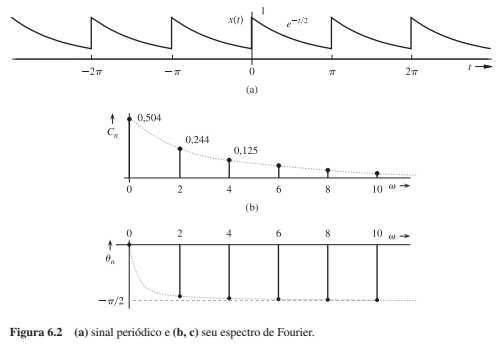

Neste caso, o período é $T_0=\pi$ e a frequência fundamental é $f_0=1 / T_0=1 / \pi \mathrm{~Hz}$ e
$$
\omega_0=\frac{2 \pi}{T_0}=2 \mathrm{~rad} / \mathrm{s}
$$

Portanto,
$$
x(t)=a_0+\sum_{n=1}^{\infty} a_n \cos 2 n t+b_n \operatorname{sen} 2 n t
$$
na qual
$$
a_0=\frac{1}{\pi} \int_{T_0} x(t) d t
$$
Neste exemplo, a escolha óbvia para o intervalo de integração é de 0 a $\pi$. Logo,
$$
\begin{aligned}
& a_0=\frac{1}{\pi} \int_0^\pi e^{-t / 2} d t \approx  0,504 \\
& a_n=\frac{2}{\pi} \int_0^\pi e^{-t / 2} \cos 2 n t d t\approx 0,504\left(\frac{2}{1+16 n^2}\right)
\end{aligned}
$$

e 

$$
b_n=\frac{2}{\pi} \int_0^\pi e^{-t / 2} \operatorname{sen} 2 n t d t \approx 0,504\left(\frac{8 n}{1+16 n^2}\right)
$$
Portanto,
$$
x(t)=0,504\left[1+\sum_{n=1}^{\infty} \frac{2}{1+16 n^2}(\cos 2 n t+4 n \operatorname{sen} 2 n t)\right]
$$
Além disso,
$$
\begin{aligned}
& C_0=a_0=0,504 \\
& C_n=\sqrt{a_n^2+b_n^2}=0,504 \sqrt{\frac{4}{\left(1+16 n^2\right)^2}+\frac{64 n^2}{\left(1+16 n^2\right)^2}}=0,504\left(\frac{2}{\sqrt{1+16 n^2}}\right) \\
& \theta_n=\tan ^{-1}\left(\frac{-b_n}{a_n}\right)=\tan ^{-1}(-4 n)=-\tan ^{-1} 4 n
\end{aligned}
$$

As amplitudes e fases da componente contínua (cc) e das primeira sete harmônicas são calculadas usando as equações acima. Podemos utilizar valores numéricos para expressar $x(t)$ por
$$
\begin{aligned}
x(t)= & 0,504+0,504 \sum_{n=1}^{\infty} \frac{2}{\sqrt{1+16 n^2}} \cos \left(2 n t-\tan ^{-1} 4 n\right) \\
x(t)= & 0,504+0,244 \cos \left(2 t-75,96^{\circ}\right)+0,125 \cos \left(4 t-82,87^{\circ}\right) \\
& +0,084 \cos \left(6 t-85,24^{\circ}\right)+0,063 \cos \left(8 t-86,42^{\circ}\right)+\cdots
\end{aligned}
$$


O espectro de amplitude e fase para $x(t)$, na Fig. $6.2 \mathrm{~b}$ e $6.2 \mathrm{c}$, nos mostra a composição em frequência de $x(t)$, ou seja, as amplitudes e fases de várias componentes senoidais de $x(t)$. 

Conhecendo o espectro de frequência, podemos reconstruir $x(t)$, como mostrado no lado direito da Eq. (6.15b). Portanto, o espectro de frequências (Fig. 6.2b, 6.2c) fornece uma descrição alternativa - **a descrição no domínio da frequência** de $x(t)$. A descrição no domínio do tempo de $x(t)$ é mostrada na Fig. 6.2a. 

<p style="color: blue">Um sinal, portanto, possui uma identidade dual: a identidade no domínio do tempo $x(t)$ e a identidade no domínio da frequencia (espectro de Fourier). </p>


As duas identidades são complementares uma da outra, e, quando juntas, possibilitam um melhor entendimento do sinal.
Um aspecto interessante da série de Fourier é que sempre que houver um salto de descontinuidade em $x(t)$, a série no ponto de descontinuidade converge para uma média dos limites do lado direito e lado esquerdo de $x(t)$ no instante da descontinuidade. 

No caso apresentado, por exemplo, $x(t)$ é descontínuo em $t=0$ com $ x\left(0^{+}\right)$ $=1$ e $x\left(0^{-}\right)=x(\pi)=e^{-\pi / 2}=0,208$. A série de Fourier correspondente converge para o valor $(1+0,208) / 2=$ $0,604$ em $t=0$. 


**Exemplo 3.6**

Determine a série trigonométrica compacta de Fourier para o sinal triangular periódico $x(t)$ mostrado na Fig. 6.3a e trace o espectro de amplitude e fase de $x(t)$.

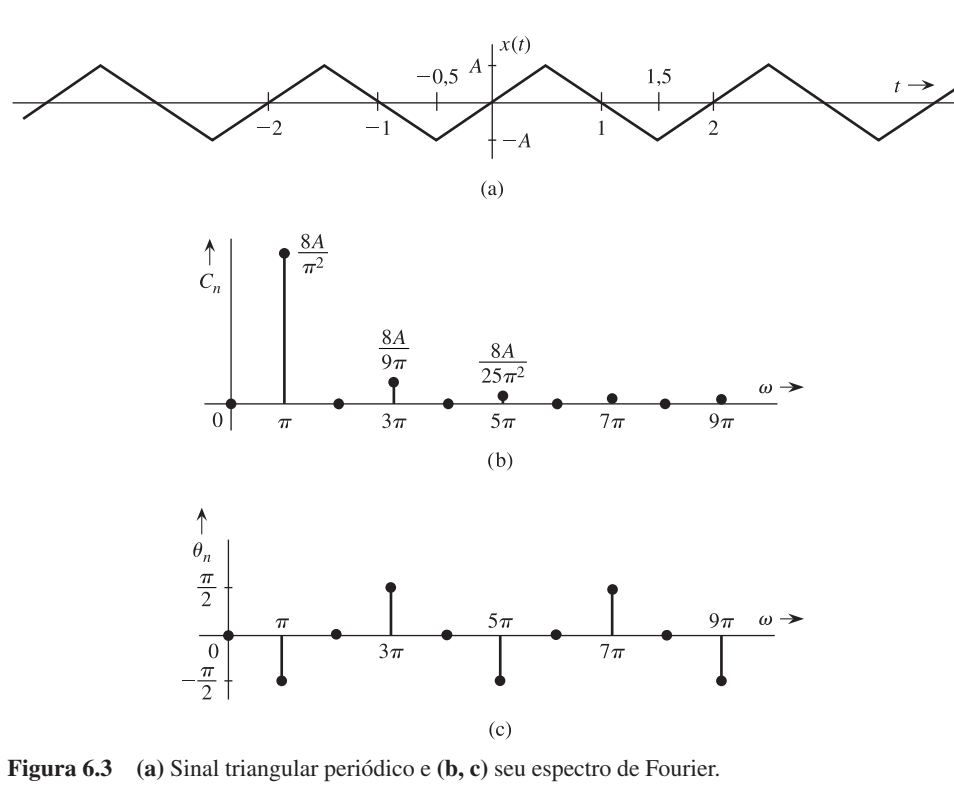

Neste caso, o período é $T_0=2$. Logo,
$$
\omega_0=\frac{2 \pi}{2}=\pi
$$
e
$$
x(t)=a_0+\sum_{n=1}^{\infty} a_n \cos n \pi t+b_n \operatorname{sen} n \pi t
$$
na qual
$$
x(t)= \begin{cases}2 A t & |t|<\frac{1}{2} \\ 2 A(1-t) & \frac{1}{2}<t<\frac{3}{2}\end{cases}
$$
Neste caso, será vantajoso escolher o intervalo de integração de $-1 / 2$ a $3 / 2$, em vez de um de 0 a 2 .
Uma rápida análise na Fig. 6.3a mostra que o valor médio (cc) de $x(t)$ é zero, tal que $a_0=0$. Além disso,

$$
\begin{aligned}
a_n & =\frac{2}{2} \int_{-1 / 2}^{3 / 2} x(t) \cos n \pi t d t \\
& =\int_{-1 / 2}^{1 / 2} 2 A t \cos n \pi t d t+\int_{1 / 2}^{3 / 2} 2 A(1-t) \cos n \pi t d t
\end{aligned}
$$
A determinação detalhada dessas integrais mostra que ambas possuem valor zero. Portanto,
$$
\begin{aligned}
& a_n=0 \\
& b_n=\int_{-1 / 2}^{1 / 2} 2 A t \operatorname{sen} n \pi t d t+\int_{1 / 2}^{3 / 2} 2 A(1-t) \operatorname{sen} n \pi t d t
\end{aligned}
$$
O cálculo detalhado dessa integral resulta em
$$
\begin{aligned}
b_n & =\frac{8 A}{n^2 \pi^2} \operatorname{sen}\left(\frac{n \pi}{2}\right) \\
& = \begin{cases}0 & n \text { par } \\
\frac{8 A}{n^2 \pi^2} & n=1,5,9,13, \ldots \\
-\frac{8 A}{n^2 \pi^2} & n=3,7,11,15, \ldots\end{cases}
\end{aligned}
$$

Portanto,
$$
x(t)=\frac{8 A}{\pi^2}\left[\operatorname{sen} \pi t-\frac{1}{9} \operatorname{sen} 3 \pi t+\frac{1}{25} \operatorname{sen} 5 \pi t-\frac{1}{49} \operatorname{sen} 7 \pi t+\cdots\right]
$$
Para traçar o espectro de Fourier, a série deve ser convertida para a forma trigonométrica compacta. Neste caso, podemos fazer rapidamente essa mudança convertendo os termos em seno para termos em cosseno com um deslocamento de fase adequado. Por exemplo,
$$
\begin{aligned}
\operatorname{sen} k t & =\cos \left(k t-90^{\circ}\right) \\
-\operatorname{sen} k t & =\cos \left(k t+90^{\circ}\right)
\end{aligned}
$$
Usando essas identidades, a equação acima pode ser expressa por

$$
\begin{aligned}
x(t)=\frac{8 A}{\pi^2}\left[\cos \left(\pi t-90^{\circ}\right)\right. & +\frac{1}{9} \cos \left(3 \pi t+90^{\circ}\right)+\frac{1}{25} \cos \left(5 \pi t-90^{\circ}\right) \\
& \left.+\frac{1}{49} \cos \left(7 \pi t+90^{\circ}\right)+\cdots\right]
\end{aligned}
$$
Nesta série, todas as harmônicas pares estão ausentes. As fases das harmônicas ímpares se alteram de $-90^{\circ}$ para $90^{\circ}$. A Fig. 6.3 mostra o espectro de amplitude e fase de $x(t)$.

**Exemplo 3.7**

Um sinal periódico $x(t)$ é representado por uma série trigonométrica de Fourier como
$$
x(t)=2+3 \cos 2 t+4 \operatorname{sen} 2 t+2 \operatorname{sen}\left(3 t+30^{\circ}\right)-\cos \left(7 t+150^{\circ}\right)
$$
Expresse essa série como uma série trigonométrica compacta de Fourier e trace o espectro de amplitude e fase de $x(t)$.


Na série trigonométrica compacta de Fourier, os termos em seno e cosseno de mesma frequência são combinados em um único termo e todos os termos são descritos na forma de cosseno com amplitudes positivas. Temos, portanto:

$$
3 \cos 2 t+4 \operatorname{sen} 2 t=5 \cos \left(2 t-53,13^{\circ}\right)
$$
Além disso,
$$
\operatorname{sen}\left(3 t+30^{\circ}\right)=\cos \left(3 t+30^{\circ}-90^{\circ}\right)=\cos \left(3 t-60^{\circ}\right)
$$
e
$$
-\cos \left(7 t+150^{\circ}\right)=\cos \left(7 t+150^{\circ}-180^{\circ}\right)=\cos \left(7 t-30^{\circ}\right)
$$
Portanto,
$$
x(t)=2+5 \cos \left(2 t-53,13^{\circ}\right)+2 \cos \left(3 t-60^{\circ}\right)+\cos \left(7 t-30^{\circ}\right)
$$
Neste caso, apenas quatro componentes (incluindo a cc) estão presentes. A amplitude cc é 2 . As três componentes restantes possuem frequiência $\omega=2,3$ e 7 , amplitudes 5,2 e 1 e fases $-53,13^{\circ},-60^{\circ}$ e $-30^{\circ}$, respectivamente. O espectro de amplitude e fase para esse sinal está mostrado na Fig. 6.4a e 6.4b, respectivamente.

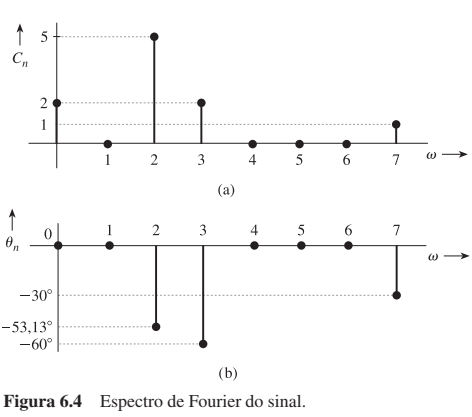

**Exemplo 3.8**

Determine a série trigonométrica compacta de Fourier para o sinal de pulso quadrado mostrado na Fig. $6.5 \mathrm{a}$ e trace seu espectro de amplitude e fase.


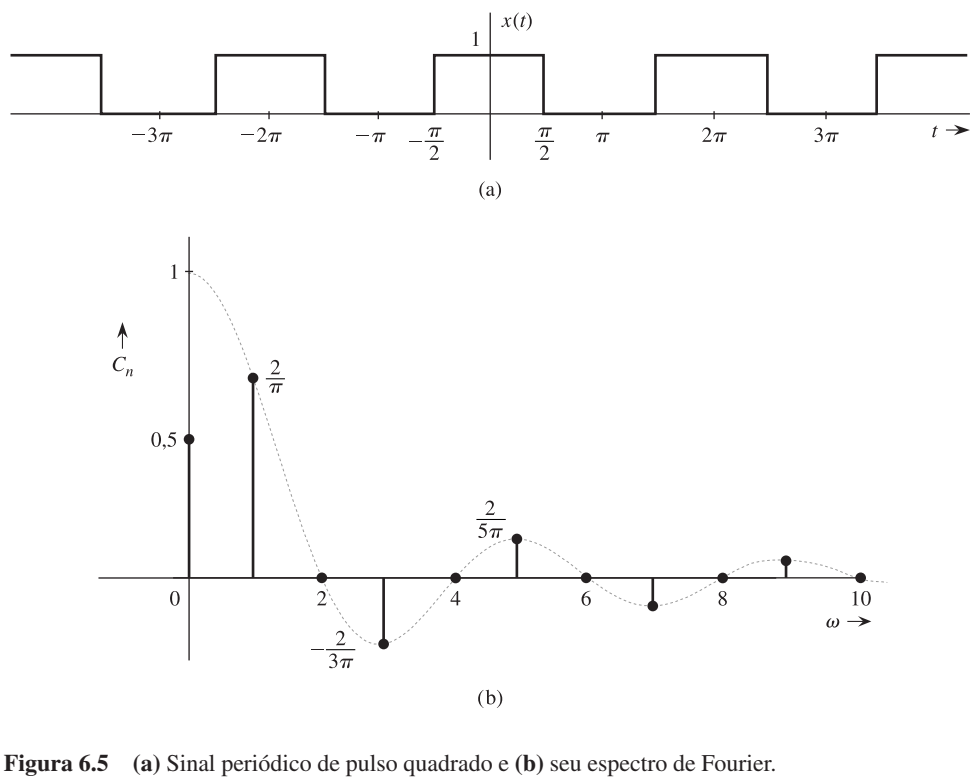

Neste caso, o período é $T_0=2 \pi$ e $\omega_0=2 \pi / T_0=1$. Portanto,
$$
x(t)=a_0+\sum_{n=1}^{\infty} a_n \cos n t+b_n \operatorname{sen} n t
$$

na qual
$$
a_0=\frac{1}{T_0} \int_{T_0} x(t) d t
$$
A partir da Fig. 6.5a, fica claro que a escolha adequada da região de integração é de $-\pi$ a $\pi$. Mas como $x(t)=1$ somente em $(-\pi / 2, \pi / 2)$ e $x(t)=0$ para o segmento restante,
$$
a_0=\frac{1}{2 \pi} \int_{-\pi / 2}^{\pi / 2} d t=\frac{1}{2}
$$
Também poderíamos ter determinado $a_0$, o valor médio de $x(t)$ como sendo $1 / 2$ simplesmente por inspeção de $x(t)$ na Fig. 6.5a. Além disso,
$$
\begin{aligned}
a_n & =\frac{1}{\pi} \int_{-\pi / 2}^{\pi / 2} \cos n t d t=\frac{2}{n \pi} \operatorname{sen}\left(\frac{n \pi}{2}\right) \\
& = \begin{cases}0 & n \text { par } \\
\frac{2}{\pi n} & n=1,5,9,13, \ldots \\
-\frac{2}{\pi n} & n=3,7,11,15, \ldots\end{cases}
\end{aligned}
$$

Portanto,
$$
x(t)=\frac{1}{2}+\frac{2}{\pi}\left(\cos t-\frac{1}{3} \cos 3 t+\frac{1}{5} \cos 5 t-\frac{1}{7} \cos 7 t+\cdots\right)
$$
Observe que $b_n=0$ e todos os termos em seno são nulos. Apenas os termos em cosseno aparecem na série trigonométrica. A série, portanto, já está na forma compacta exceto pelas amplitudes das harmônicas alternantes que são negativas. Pela definição, as amplitudes $C_n$ são positivas. O sinal negativo pode ser acomodado associando uma fase adequada ao tempo.
$$
-\cos x=\cos (x-\pi)
$$
Usando esse fato, podemos expressar a série como 
$$
\begin{aligned}
x(t)=\frac{1}{2} & +\frac{2}{\pi}\left[\cos \omega_0 t+\frac{1}{3} \cos \left(3 \omega_0 t-\pi\right)+\frac{1}{5} \cos 5 \omega_0 t\right. \\
& \left.+\frac{1}{7} \cos \left(7 \omega_0 t-\pi\right)+\frac{1}{9} \cos 9 \omega_0 t+\cdots\right]
\end{aligned}
$$
Essa é a forma desejada da série trigonométrica compacta de Fourier. As amplitudes são

\begin{gathered}
C_0=\frac{1}{2} \\
C_n= \begin{cases}0 & n \text { par } \\
\frac{2}{\pi n} & n \text { ímpar }\end{cases}
\end{gathered}

$$
\theta_n= \begin{cases}0 & \text { para todo } n \neq 3,7,11,15, \ldots \\ -\pi & n=3,7,11,15, \ldots\end{cases}
$$
Podemos utilizar esses valores para traçar o espectro de amplitude e fase. Entretanto, podemos simplificar nossa tarefa neste caso especial se permitirmos que a amplitude $C_n$ assuma valores negativos. Se isso for permitido, não precisamos de uma fase de $-\pi$ para considerar o sinal observado acima. 

Isso significa que as fases de todas as componentes são zero e podemos descartar o espectro de fase, trabalhando apenas com o espectro de amplitude, como mostrado na Fig. 6.5b. Observe que não há perda de informação quando fazemos essa consideração e que o espectro de amplitude da Fig. $6.5 \mathrm{~b}$ possui a informação completa sobre a série de Fourier.

Portanto, quando todos os termos em seno desaparecem $\left(b_n=0\right)$, é conveniente permitir que $C_n$ assuma valores negativos. Isso permite que a informação espectral esteja contida em um único espectro. 

Vamos investigar, agora, o comportamento da série em pontos de descontinuidade. Para a descontinuidade em $t=\pi / 2$, os valores de $x(t)$ nos dois lados da descontinuidade são $x\left((\pi / 2)^{-}\right)=1$ e $x\left((\pi / 2)^{+}\right)=0$. Podemos verificar, fazendo $t=\pi / 2$, que $x(\pi / 2)=0,5$, o qual é o valor médio entre os valores de $x(t)$ nos dois lados da descontinuidade em $t=\pi / 2$

#### Efeito da Simetria

Em alguns dos exemlos apresentados acima, a série de Fourier é constituída de termos em seno e cosseno, ou apenas por termos em seno, ou ainda constituída somente por termos em cosseno. Isso não acontece por acaso. 

Podemos mostrar que a série de Fourier de qualquer função periódica **par** $x(t)$ é **constituída por termos apenas em cosseno** e que série para qualquer função periódica **ímpar** $x(t)$ é **constituída apenas por termos em seno**. 

Além disso, devido à simetria (par ou ímpar), a informação de um período de $x(t)$ está implícita em apenas meio período. Nesses casos, conhecendo o sinal em meio período e conhecendo o tipo de simetria (par ou ímpar), podemos determinar a forma de onda do sinal para todo o período. Por essa razão, os coeficientes de Fourier nesses casos podem ser calculados integrando-se apenas em meio período, em vez de em todo o período. Para provar esse resultado, lembre-se que
$$
\begin{aligned}
& a_0=\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} x(t) d t \\
& a_n=\frac{2}{T_0} \int_{-T_0 / 2}^{T_0 / 2} x(t) \cos n \omega_0 t d t \\
& b_n=\frac{2}{T_0} \int_{-T_0 / 2}^{T_0 / 2} x(t) \operatorname{sen} n \omega_0 t d t
\end{aligned}
$$

Lembre-se também, de que $\cos n \omega_0 t$ é uma função par e sen $n \omega_0 t$ é uma função ímpar de $t$. Se $x(t)$ é uma função par de $t$, então $x(t) \cos n \omega_0 t$ também é uma função par e $x(t)$ sen $n \omega_0 t$ será uma função ímpar de $t$. Portanto, 

$$
\begin{aligned}
a_0 &=\frac{2}{T_0} \int_0^{T_0 / 2} x(t) d t \\
a_n &=\frac{4}{T_0} \int_0^{T_0 / 2} x(t) \cos n \omega_0 t d t \\
b_n &=0
\end{aligned}
$$


Similarmente, se $x(t)$ é uma função ímpar de $t$, então $x(t) \cos n \omega_0 t$ é uma função ímpar de $t$ e $x(t)$ sen $n \omega_0 t$ é uma função par de $t$. Portanto,
$$
\begin{aligned}
a_n &=0 \quad \text { para todo } n \\
b_n &=\frac{4}{T_0} \int_0^{T_0 / 2} x(t) \operatorname{sen} n \omega_0 t d t
\end{aligned}
$$
Observe que, devido à simetria, a integração necessária para calcular os coeficientes deve ser executada apenas em meio período.


#### Existência e Convergência da Série de Fourier

Para a existência da série de Fourier, os coeficientes $a_0, a_n$ e $b_n$ devem ser finitos, o que é garantido se $x(t)$ for absolutamente integrável em um período, ou seja,
$$
\int_{T_0}|x(t)| d t<\infty
$$

Um conjunto alternativo de critérios, devido a Dirichlet, para a convergência da série de Fourier, é denominado de 

**Condições de Dirichlet**

Dirichlet mostrou que se $x(t)$ satisfaz certas condições (condições de Dirichlet), a convergência para o ponto de sua série de Fourier é garantida para todos os pontos nos quais $x(t)$ é contínua. Além disso, nos pontos de descontinuidade, $x(t)$ converge para o valor médio entre os dois valores de $x(t)$ dos dois lados da descontinuidade. Essas condições são:

1. A função $x(t)$ deve ser absolutamente integrável;

2. A função $x(t)$ deve ter apenas um número finito de descontinuidades finitas em um período;

3. A função $x(t)$ deve conter apenas um número finito de máximos ou mínimos em um período;

Todos os sinais práticos satisfazem essas condições.




#### Espectro Exponencial de Fourier

No espectro exponencial, traçamos os coeficientes $D_n$ em função de $\omega$. Mas como $D_n$ é, geralmente, complexo, precisamos das duas partes de um dos conjuntos de gráficos: a parte real e imaginária de $D_n$, ou a magnitude e ângulo de $D_n$. Geralmente prefere-se a última porque existe uma conexão mais próxima com as amplitudes e fases das componentes correspondentes da série trigonométrica de Fourier. 


Portanto, iremos traçar $\left|D_n\right|$ em função de $\omega$ e $\angle D_n$ em função de $\omega$. Para isso, precisamos que os coeficientes $D_n$ sejam expressos na forma polar como $\left|D_n\right| e^{j \angle D n}$, na qual $\left|D_n\right|$ são as amplitudes e $\angle D_n$ são as fases das várias componentes exponenciais. 



Lembrando que a série exponencial de Fourier pode ser descrita por
$$
x(t)=\sum_{n=-\infty}^{\infty} D_n e^{j n \omega_0 t}
$$
na qual
$$
D_n=\frac{1}{T_0} \int_{T_0} x(t) e^{-j n \omega_0 t} d t
$$


Podemos relacionar $D_n$ com os coeficientes $a_n$ e $b_n$ da série trigonométrica. Fazendo $n=0$, obtemos
$$
D_0=a_0
$$
Além disso, para $n \neq 0$,
$$
D_n=\frac{1}{T_0} \int_{T_0} x(t) \cos n \omega_0 t d t-\frac{j}{T_0} \int_{T_0} x(t) \operatorname{sen} n \omega_0 t d t=\frac{1}{2}\left(a_n-j b_n\right)
$$
$\mathrm{e}$
$$
D_{-n}=\frac{1}{T_0} \int_{T_0} x(t) \cos n \omega_0 t d t+\frac{j}{T_0} \int_{T_0} x(t) \operatorname{sen} n \omega_0 t d t=\frac{1}{2}\left(a_n+j b_n\right)
$$
Esses resultados são válidos para $x(t)$ genérico, real ou complexo. 

Quando $x(t)$ é real, $a_n$ e $b_n$ são reais, mostramos que $D_n$ e $D_{-n}$ são conjugados.
$$
D_{-n}=D_n^*
$$
Além disso, observamos que
$$
a_n-j b_n=\sqrt{a_n^2+b_n^2} e^{j \tan ^{-1}\left(\frac{b_n}{a_n}\right)}=C_n e^{j \theta_n}
$$


Logo
$$
D_0=a_0=C_0
$$
e
$$
D_n=\frac{1}{2} C_n e^{j \theta_n} \quad D_{-n}=\frac{1}{2} C_n e^{-j \theta_n}
$$
Portanto,
$$
\begin{gathered}
\left|D_n\right|=\left|D_{-n}\right|=\frac{1}{2} C_n \quad n \neq 0 \\
\angle D_n=\theta_n \quad \angle D_{-n}=-\theta_n
\end{gathered}
$$
Note que $\left|D_n\right|$ são as amplitudes e $\angle D_n$ são os ângulos das várias componentes exponenciais. A partir das equações acima, temos que quando $x(t)$ é real, o espectro de amplitude ( $\left|D_n\right|$ em função de $\omega$ ) é uma função par de $\omega$ e o espectro de ângulo ( $\angle D_n$ em função de $\left.\omega\right)$ é uma função ímpar de $\omega$. Para $x(t)$ complexo, $D_n$ e $D_{-n}$ são geralmente não conjugados.

**Exemplo 3.8**

O espectro trigonométrico de Fourier de um certo sinal periódico $x(t)$ está mostrado na Fig. 6.11a. Por inspeção desse espectro, trace o espectro exponencial de Fourier correspondente e verifique analiticamente seus resultados.


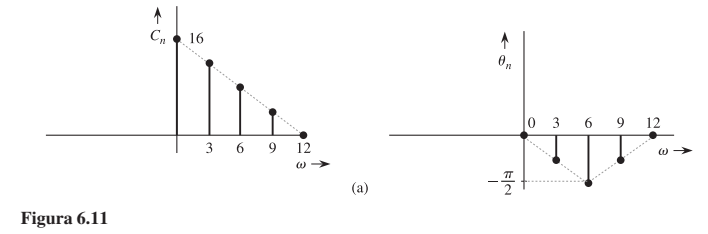



**Exercício 1 - Lista 2b**

## 4. Análise de Sinais no Tempo Contínuo: A Trasnformada de Fourier



### 4.1 Representação de Sinais não Periódicos Pela Integral de Fourier

Aplicando um processo de limite, iremos mostrar que um sinal não periódico pode ser descrito pela soma contínua (integral) de exponenciais de duração infinita. Para representar um sinal não periódico $x(t)$, tal como o mostrado na Fig. 7.1a, por exponenciais de duração infinita, vamos construir um novo sinal periódico $x_{T_0}(t)$ formado pela repetição do sinal $x(t)$ em intervalos de $T_0$ segundos, como ilustrado na Fig. 7.1b. 


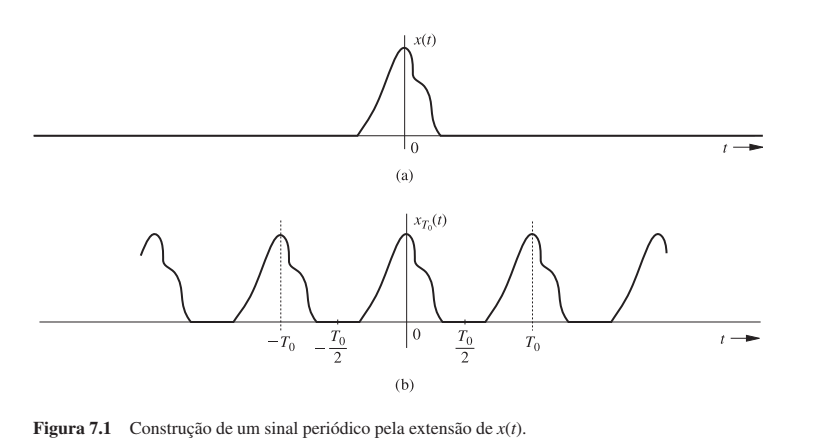



O período $T_0$ é feito grande o suficiente para evitar a sobreposição entre pulsos seguidos. O sinal periódico $x_{T_0}(t)$ pode ser representado por uma série exponencial de Fourier. Se fizermos $T_0 \rightarrow \infty$, os pulso no sinal periódico irão se repetir após um intervalo infinito, portanto,
$$
\lim _{T_0 \rightarrow \infty} x_{T_0}(t)=x(t)
$$
Dessa forma, a série de Fourier que representa $x_{T_0}(t)$ também irá representar $x(t)$ no limite de $T_0 \rightarrow \infty$. A série exponencial de Fourier para $x_{T_0}(t)$ é dada por
$$
x_{T_0}(t)=\sum_{n=-\infty}^{\infty} D_n e^{j n \omega_0 t}
$$
na qual
$$
D_n=\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} x_{T_0}(t) e^{-j n \omega_0 t} d t
$$

$$
\omega_0=\frac{2 \pi}{T_0}
$$
Observe que integrar $x_{T_0}(t)$ em $\left(-T_0 / 2, T_0 / 2\right)$ é o mesmo que integrar $x(t)$ em $(-\infty, \infty)$. Portanto, podemos reescrever
$$
D_n=\frac{1}{T_0} \int_{-\infty}^{\infty} x(t) e^{-j n \omega_0 t} d t
$$
É interessante ver como a natureza do espectro muda quando $T_0$ aumenta. Para compreender esse fascinante comportamento, vamos definir $X(\omega)$, uma função contínua de $\omega$, por
$$
X(\omega)=\int_{-\infty}^{\infty} x(t) e^{-j \omega t} d t
$$
Uma rápida análise das equações acima mostra que
$$
D_n=\frac{1}{T_0} X\left(n \omega_0\right)
$$


Isso significa que os coeficientes $D_n$ de Fourier são $1 / T_0$ vezes as amostras de $X(\omega)$ uniformemente espaçados em intervalos de $\omega_0$, como mostrado na Fig. 7.2a. 


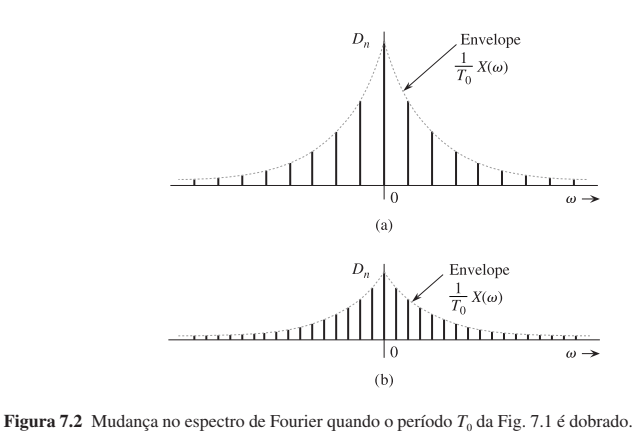

Portanto, $\left(1 / T_0\right) X(\omega)$ é o envelope para os coeficientes $D_n$. Iremos fazer, agora, $T_0 \rightarrow \infty$ dobrando o valor de $T_0$ repetidamente. Dobrando $T_0$ dividimos a frequência fundamental $\omega_0$, de tal forma que teremos agora duas vezes mais componentes (amostras) no espectro. 

Entretanto, dobrando $T_0$, o envelope $\left(1 / T_0\right) X(\omega)$ é dividido pela metade, como mostrado na Fig. 7.2b. Se continuarmos nesse processo de dobrar $T_0$ repetidamente, o espectro progressivamente se torna mais denso enquanto que sua magnitude se torna menor. 

Observe, entretanto, que a forma relativa do envelope permanece a mesma [proporcional a $X(\omega)$ na Eq. (7.3)]. No limite, quando $T_0 \rightarrow \infty, \omega_0 \rightarrow 0$ e $D_n \rightarrow 0$. Esse resultado torna o espectro tão denso que as componentes espectrais ficam espaçadas com intervalos nulos (infinitesimais). 


A substituição adequada das equações acima resulta em
$$
x_{T_0}(t)=\sum_{n=-\infty}^{\infty} \frac{X\left(n \omega_0\right)}{T_0} e^{j n \omega_0 t}
$$
Quando $T_0 \rightarrow \infty, \omega_0$ se torna infinitesimal $\left(\omega_0 \rightarrow 0\right)$. Logo, podemos substituir $\omega_0$ por uma notação mais apropriada, $\Delta \omega$. Em termos dessa nova notação, temos
$$
\Delta \omega=\frac{2 \pi}{T_0}
$$
e
$$
x_{T_0}(t)=\sum_{n=-\infty}^{\infty}\left[\frac{X(n \Delta \omega) \Delta \omega}{2 \pi}\right] e^{(j n \Delta \omega) t}
$$
A última equação mostra que $x_{T_0}(t)$ pode ser descrito pela soma de exponenciais de duração exponencial de frequências $0, \pm \Delta \omega, \pm 2 \Delta \omega, \pm 3 \Delta \omega, \ldots$ (a série de Fourier). O total de componentes de freqüência $n \Delta \omega$ é $[X(n \Delta \omega) \Delta \omega] / 2 \pi$. No limite, quando $T_0 \rightarrow \infty, \Delta \omega \rightarrow 0$ e $x_{T_o}(t) \rightarrow x(t)$. Portanto,

$$
\begin{aligned}
x(t) & =\lim _{T_0 \rightarrow \infty} x_{T_0}(t) \\
& =\lim _{\Delta \omega \rightarrow 0} \frac{1}{2 \pi} \sum_{n=-\infty}^{\infty} X(n \Delta \omega) e^{(j n \Delta \omega) t} \Delta \omega
\end{aligned}
$$
A soma do lado direito da equação acima pode ser entendida como a área sob a função $X(\omega) e^{j \omega t}$, como ilustrado na Fig. 7.3. 

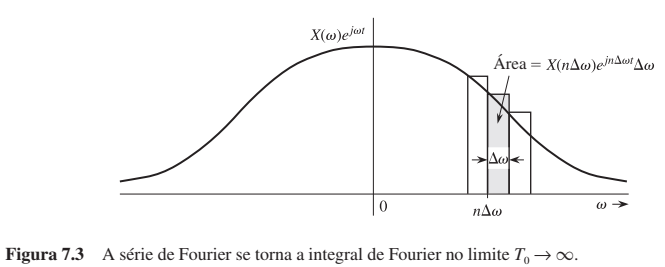

Assim sendo,
$$
x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega
$$
A integral do lado direito é chamada de **integral de Fourier**. Neste momento, acabamos de obter sucesso na representação de um sinal não periódico $x(t)$ pela integral de Fourier (em vez da série de Fourier). 


Essa integral é basicamente a série de Fourier (no limite) com frequência fundamental $\Delta \omega \rightarrow 0$. O total da exponencial $e^{j n \Delta \omega t}$ é $X(n \Delta \omega) \Delta \omega / 2 \pi$. Portanto, a função $X(\omega)$ dada funciona como função espectral.

<p style="color: blue">Chamamos $X(\omega)$ de transformada de Fourier direta de $x(t)$ e $x(t)$ de transformada de Fourier inversa de $X(\omega)$. A mesma informação é contida na afirmação de que $x(t)$ e $X(\omega)$ são um par transformada de Fourier. Simbolicamente, essa afirmativa pode ser expressa por
$$
X(\omega)=\mathcal{F}[x(t)] \quad \text { e } \quad x(t)=\mathcal{F}^{-1}[X(\omega)]
$$
ou
$$
x(t) \Longleftrightarrow X(\omega)
$$
Recapitulando,
$$
x(t) \Longleftrightarrow X(\omega)
$$
e
$$
x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega
$$ </p>

É útil manter em mente que a integral de Fourier ($x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega$) é da natureza da série de Fourier com frequência fundamental $\Delta \omega$ aproximando de zero. Portanto, a maior parte das discussões e propriedades da série de Fourier se aplicam à transformada de Fourier. A transformada $X(\omega)$ é a especificação no domínio da frequência de $x(t)$.

Podemos traçar o espectro de $X(\omega)$ em função de $\omega$. Como $X(\omega)$ é complexo, teremos tanto o espectro de amplitude quanto o de ângulo (ou fase)
$$
X(\omega)=|X(\omega)| e^{j \angle X(\omega)}
$$
na qual $|X(\omega)|$ é a amplitude e $\angle X(\omega)$ é o ângulo (ou fase) de $X(\omega)$. 

De acordo com definição,
$$
X(-\omega)=\int_{-\infty}^{\infty} x(t) e^{j \omega t} d t
$$
Tomando os conjugados dos dois lados dessa equação, teremos
$$
x^*(t) \Longleftrightarrow X^*(-\omega)
$$
Essa propriedade é conhecida como **propriedade do conjugado**. 

Agora, se $x(t)$ for uma função real de $t$, então $x(t)=x^*(t)$ e da propriedade do conjugado, temos que
$$
X(-\omega)=X^*(\omega)
$$
Essa é a **propriedade da simetria de conjugado da transformada de Fourier**, aplicável a $x(t)$ real. Portanto, para $x(t)$ real

$$
\begin{aligned}
|X(-\omega)| &= |X(\omega)|\\
\angle X(-\omega) &=- \angle X(\omega)
\end{aligned}
$$

Portanto, para $x(t)$ real, o espectro de amplitude $|X(\omega)|$ é uma função par e o espectro de fase $\angle X(\omega)$ é uma função ímpar de $\omega$. Esses resultados também foram obtidos anteriormente, para o espectro de Fourier de um sinal periódico.

**Exemplo 4.1**

Determine a transformada de Fourier de $e^{-a t} u(t)$.